# How to train & deploy a dog classifier using Amazon Sagemaker

This notebook lists all the steps that you need to complete the complete this project. You will need to complete all the TODOs in this notebook as well as in the README and the two python scripts included with the starter code.


**TODO**: Give a helpful introduction to what this notebook is for. Remember that comments, explanations and good documentation make your project informative and professional.

**Note:** This notebook has a bunch of code and markdown cells with TODOs that you have to complete. These are meant to be helpful guidelines for you to finish your project while meeting the requirements in the project rubrics. Feel free to change the order of these TODO's and use more than one TODO code cell to do all your tasks.

In [1]:
# TODO: Install any packages that you might need
# For instance, you will need the smdebug package
!pip install smdebug

In [2]:
# TODO: Import any packages that you might need
# For instance you will need Boto3 and Sagemaker
import sagemaker
import boto3

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


## Dataset

For this project, the <b>dogImages</b> dataset provided here -> https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip <- is used.

The dataset is already split into train, test and validation subsets, containing 
- more than 6600 train images
- around 830 test images
- around 830 validation images

Each subset contains multiple images of 133 different dog classes in class-specific subfolders, like 
- Australian terriers
- Beagles
- Cocker spaniels

An exemplary image of an Australian terrier is shown below.

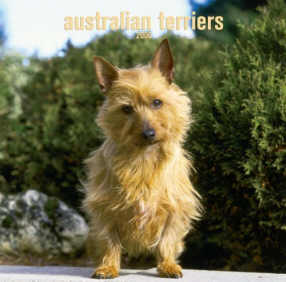

### Fetch and upload the data to AWS S3

In [3]:
# Command to download and unzip data
!wget https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
!unzip dogImages.zip

--2026-04-29 05:40:34--  https://s3-us-west-1.amazonaws.com/udacity-aind/dog-project/dogImages.zip
Resolving s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)... 16.15.0.194, 16.15.0.14, 52.219.216.144, ...
Connecting to s3-us-west-1.amazonaws.com (s3-us-west-1.amazonaws.com)|16.15.0.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1132023110 (1.1G) [application/zip]
Saving to: ‘dogImages.zip’

dogImages.zip       100%[===================>]   1.05G  47.6MB/s    in 24s     

2026-04-29 05:40:58 (45.7 MB/s) - ‘dogImages.zip’ saved [1132023110/1132023110]

Archive:  dogImages.zip
replace dogImages/test/001.Affenpinscher/Affenpinscher_00003.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [7]:
import sagemaker
from sagemaker import get_execution_role

sess = sagemaker.Session()
role = get_execution_role()

In [8]:
folder = "dogImages"
prefix = "dogImagesDataset"
bucket = "uda-mleng-project3"

In [10]:
print("Starting to upload dogImages to S3...")
inputs = sess.upload_data(path="dogImages", bucket=bucket, key_prefix=prefix)
#inputs = "s3://uda-mleng-project3/dogImagesDataset"
print(f"Input path ( S3 file path ): {inputs}")

Starting to upload dogImages to S3...
Input path ( S3 file path ): s3://uda-mleng-project3/dogImagesDataset


In [11]:
# Check if data is available in S3 bucket:
import boto3

s3 = boto3.client("s3")
response = s3.list_objects_v2(
    Bucket="uda-mleng-project3",
    Prefix="dogImagesDataset/"
)

for obj in response.get("Contents", []):
    print(obj["Key"], obj["Size"])

dogImagesDataset/inference/ 0
dogImagesDataset/inference/DuckToller.jpg 72153
dogImagesDataset/inference/Schaeferhund.jpg 76096
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00003.jpg 36982
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00023.jpg 79413
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00036.jpg 34092
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00047.jpg 56930
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00048.jpg 56223
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00058.jpg 73524
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00071.jpg 14307
dogImagesDataset/test/001.Affenpinscher/Affenpinscher_00078.jpg 29985
dogImagesDataset/test/002.Afghan_hound/Afghan_hound_00116.jpg 85177
dogImagesDataset/test/002.Afghan_hound/Afghan_hound_00125.jpg 16751
dogImagesDataset/test/002.Afghan_hound/Afghan_hound_00139.jpg 36103
dogImagesDataset/test/002.Afghan_hound/Afghan_hound_00141.jpg 72998
dogImagesDataset/test/002.Afghan_hound/A

## Hyperparameter Tuning
In the following, we finetune a pretrained model with hyperparameter tuning.
Here, we tune the following 2 hyperparameters (increasing this number, e.g., by additionally tuning the number of epochs, is left for future work if additional budget is provided):
- Learning Rate (LR), in ranges between 0.0001 and 0.01 (typical LR range)
- Batch Size (Batch Size), considering batch sizes of 32, 64, and 128 (typical binary numbered batch sizes)
We decided for those hyperparameters as they are typically amongst the most important ones for model performance.

To perform hyperparameter tuning, the `hpo.py` script is used.

In [12]:
!pip install torch

In [13]:
# Initializing & output some useful variables
region = sagemaker.Session().boto_region_name
print("AWS Region: {}".format(region))
sagemaker_session = sess
print("RoleArn: {}".format(role))
print(f"S3 bucket : {bucket}")

AWS Region: us-east-1
RoleArn: arn:aws:iam::646071784763:role/service-role/AmazonSageMaker-ExecutionRole-20260422T065010
S3 bucket : uda-mleng-project3


In [20]:
#TODO: Declare your HP ranges, metrics etc.

# Import Rule Configs & Training Input:
from sagemaker.debugger import Rule, rule_configs
from sagemaker.session import TrainingInput

# Import required modules from tuner
from sagemaker.tuner import (
    CategoricalParameter,
    ContinuousParameter,
    HyperparameterTuner
)

# Define Hyperparameter ranges:
hyperparameter_ranges = {
    "lr": ContinuousParameter(1e-4, 1e-2),    # Consider typical Learning Rates between 0.0001 and 0.01
    "batch_size": CategoricalParameter([32, 64, 128]), # Consider batch sizes between 32 and 128
    #"epochs": IntegerParameter(5, 10)            # Consider epoch sizes of 3 and 6 - left for future work!
}
objective_metric_name = "average test loss"
objective_type = "Minimize"
metric_definitions = [{"Name": "average test loss", "Regex": "Test set: Average loss: ([0-9\\.]+)"}]

In [21]:
import sagemaker
print(sagemaker.__version__)
print(sagemaker.__file__)

2.245.0
/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py


In [22]:
import sagemaker.pytorch
print(dir(sagemaker.pytorch))

['PyTorch', 'PyTorchModel', 'PyTorchPredictor', 'PyTorchProcessor', 'TrainingCompilerConfig', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'absolute_import', 'defaults', 'estimator', 'model', 'processing', 'training_compiler']


In [23]:
#TODO: Create estimators for your HPs
import sagemaker
from sagemaker.pytorch.estimator import PyTorch

# Estimator configuration:
estimator = PyTorch(
    entry_point = "hpo.py",
    base_job_name = "dog-breed-classification-hpo",
    role = role,
    instance_count = 1,
    instance_type = "ml.m5.2xlarge",
    hyperparameter_ranges = hyperparameter_ranges,
    py_version = "py36",
    framework_version = "1.8.1"
)

# Tuner configuration:
tuner = HyperparameterTuner(
    estimator,
    objective_metric_name=objective_metric_name,
    hyperparameter_ranges=hyperparameter_ranges,
    metric_definitions=metric_definitions,
    max_jobs=4,
    max_parallel_jobs=4,
    objective_type=objective_type,
    early_stopping_type="Auto",
)

In [24]:
# Include data channels:
input_data = f's3://{bucket}/{prefix}/'
print(f"Input path ( S3 file path ): {input_data}")

# Fit HP Tuner with input data:
tuner.fit({"train": f"{input_data}train", "test": f"{input_data}test"}, wait=True)

Input path ( S3 file path ): s3://uda-mleng-project3/dogImagesDataset/


No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config
No finished training job found associated with this estimator. Please make sure this estimator is only used for building workflow config


........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................!


In [25]:
# List the child jobs:
analytics = tuner.analytics()
df = analytics.dataframe()
print(df[["TrainingJobName", "FinalObjectiveValue", "TrainingJobStatus"]])

                             TrainingJobName  FinalObjectiveValue  \
0  pytorch-training-260429-0554-004-8d868ca7               0.0049   
1  pytorch-training-260429-0554-003-9843e6e9               0.0130   
2  pytorch-training-260429-0554-002-982246b9               0.0045   
3  pytorch-training-260429-0554-001-567e0cb0               0.0064   

  TrainingJobStatus  
0         Completed  
1         Completed  
2         Completed  
3           Stopped  


In [26]:
# TODO: Get the best estimators and the best HPs

best_estimator = tuner.best_estimator()

#Get the hyperparameters of the best trained model
hp = best_estimator.hyperparameters()
md = best_estimator.model_data


2026-04-29 06:36:02 Starting - Preparing the instances for training
2026-04-29 06:36:02 Downloading - Downloading the training image
2026-04-29 06:36:02 Training - Training image download completed. Training in progress.
2026-04-29 06:36:02 Uploading - Uploading generated training model
2026-04-29 06:36:02 Completed - Resource released due to keep alive period expiry


In [27]:
print("HP of best estimator:\n",hp)

HP of best estimator:
 {'_tuning_objective_metric': '"average test loss"', 'batch_size': '"32"', 'lr': '0.0007073488418203175', 'sagemaker_container_log_level': '20', 'sagemaker_estimator_class_name': '"PyTorch"', 'sagemaker_estimator_module': '"sagemaker.pytorch.estimator"', 'sagemaker_job_name': '"dog-breed-classification-hpo-2026-04-29-05-54-19-724"', 'sagemaker_program': '"hpo.py"', 'sagemaker_region': '"us-east-1"', 'sagemaker_submit_directory': '"s3://sagemaker-us-east-1-646071784763/dog-breed-classification-hpo-2026-04-29-05-54-19-724/source/sourcedir.tar.gz"'}


In [28]:
print("Model data path:\n",md)

Model data path:
 s3://sagemaker-us-east-1-646071784763/pytorch-training-260429-0554-002-982246b9/output/model.tar.gz


In [29]:
best_hps = {"batch_size": int(best_estimator.hyperparameters()['batch_size'].replace('"', '')), \
                   "lr": best_estimator.hyperparameters()['lr']
                  }
best_hps

{'batch_size': 32, 'lr': '0.0007073488418203175'}

### Steps to plot loss and accuracies of model training
1. Read the CloudWatch log stream with boto3
2. Regex-parse the loss and Accuracy
3. Put them into a DataFrame
4. Plot with matplotlib

In [31]:
import boto3
import re
import pandas as pd

logs = boto3.client("logs", region_name="us-east-1")

log_group = "/aws/sagemaker/TrainingJobs"
log_stream = "pytorch-training-260429-0554-001-567e0cb0/algo-1-1777442104" #"pytorch-training-260428-0544-002-79cdc969/algo-1-1777355106" #"YOUR-TRAINING-JOB-LOG-STREAM"

events = []
next_token = None

while True:
    kwargs = {
        "logGroupName": log_group,
        "logStreamName": log_stream,
        "startFromHead": True
    }
    if next_token:
        kwargs["nextToken"] = next_token

    response = logs.get_log_events(**kwargs)
    events.extend(response["events"])

    new_token = response["nextForwardToken"]
    if new_token == next_token:
        break
    next_token = new_token

pattern_batch = re.compile(
    r"epoch=(\d+)\s*batch=(\d+)\s*loss=([0-9.]+)\s*accuracy=([0-9.]+)%"
)
pattern_running = re.compile(r"Running loss\s+([0-9.]+),\s+Accuracy\s+([0-9.]+)%")

rows = []
current_epoch = None
current_batch = None
current_batch_loss = None
current_accuracy = None

for event in events:
    msg = event["message"]
    m1 = pattern_batch.search(msg)
    if m1:
        current_epoch = int(m1.group(1))
        current_batch = int(m1.group(2))
        current_batch_loss = float(m1.group(3))
        current_accuracy = float(m1.group(4))
        #print("MATCH:", m1.groups())
    
    #m2 = pattern_running.search(msg)
    #if m2 and current_epoch is not None and current_batch is not None:
        rows.append({
            "epoch": current_epoch,
            "batch": current_batch,
            "batch_loss": current_batch_loss,
            "accuracy": current_accuracy,
            #"running_loss": float(m2.group(1)),
            #"accuracy": float(m2.group(2)),
        })
        #print(f"Appended {current_epoch} - {current_batch} - {current_batch_loss} - {current_accuracy}")

df = pd.DataFrame(rows)
df.head(200)

,epoch,batch,batch_loss,accuracy
0,1,0,5.0092,0.00
1,1,10,5.0664,0.85
2,1,20,4.6833,3.57
3,1,30,4.6387,5.04
4,1,40,4.4726,6.71
...,...,...,...,...
100,5,160,0.7007,87.58
101,5,170,0.6918,87.54
102,5,180,0.7127,87.53
103,5,190,0.7533,87.60


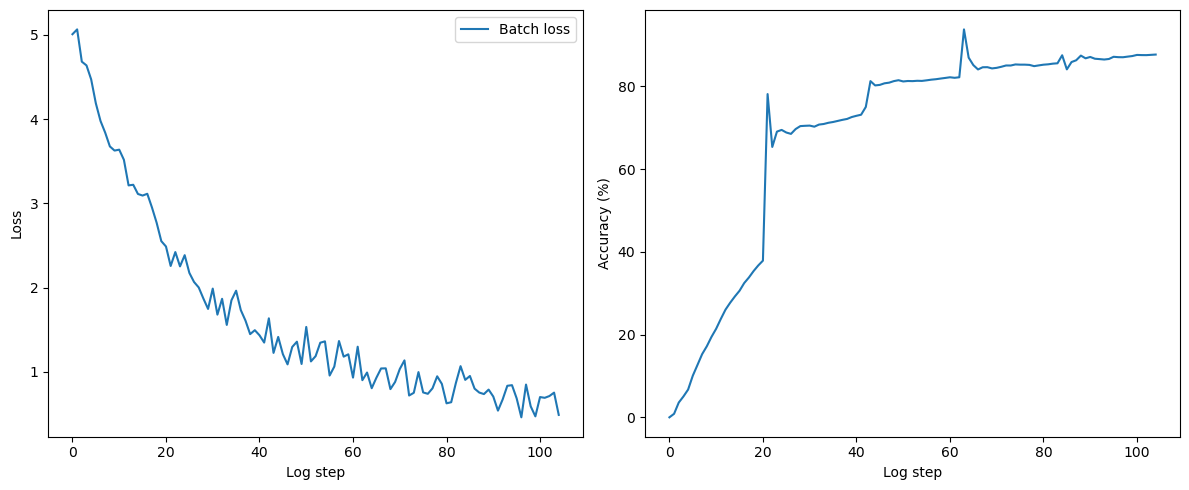

In [32]:
import matplotlib.pyplot as plt

# Plot logstream data:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df.index, df["batch_loss"], label="Batch loss")
#plt.plot(df.index, df["running_loss"], label="Running loss")
plt.xlabel("Log step")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(df.index, df["accuracy"])
plt.xlabel("Log step")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

## Model Profiling and Debugging

Using the best hyperparameters, we create and finetune a new model, using the 'train_model.py' script to perform profiling and debugging.

In [41]:
from sagemaker.debugger import ProfilerConfig, FrameworkProfile, ProfilerRule, rule_configs
from sagemaker.debugger import DebuggerHookConfig

# Setting up profiling rules:
rules = [
    Rule.sagemaker(rule_configs.vanishing_gradient()), # Profile vanishing gradients
    Rule.sagemaker(rule_configs.poor_weight_initialization()), # Profile poor weight initialization
    Rule.sagemaker(rule_configs.overfit()), # Profile overfitting
    Rule.sagemaker(rule_configs.overtraining()), # Profile overtraining
    ProfilerRule.sagemaker(rule_configs.ProfilerReport()),
]

# Setting up profiler:
profiler_config = ProfilerConfig(
    system_monitor_interval_millis=500, framework_profile_params=FrameworkProfile(num_steps=1)
)

# Setting up hook configuration:
hook_config = DebuggerHookConfig(
    hook_parameters={
        "train.save_interval": "100",
        "eval.save_interval": "10"
    }
)

See: https://sagemaker.readthedocs.io/en/stable/v2.html for details.


In [42]:
# TODO: Create and fit an estimator
estimator = PyTorch(
    entry_point="train_model.py",
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    framework_version="1.8.1",
    py_version="py3",
    hyperparameters=best_hps, # Use best hyperparameters determined above
    profiler_config=profiler_config,
    rules=rules
)

In [43]:
# TODO: Finetune & plot the debugging output.
estimator.fit({
    "train": f"{input_data}train",
    "valid": f"{input_data}valid",
    "test": f"{input_data}test"
})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:image_uri is not presented, retrieving image_uri based on instance_type, framework etc.
INFO

2026-04-29 07:21:07 Starting - Starting the training job...
2026-04-29 07:21:33 Starting - Preparing the instances for trainingVanishingGradient: InProgress
PoorWeightInitialization: InProgress
Overfit: InProgress
Overtraining: InProgress
ProfilerReport: InProgress
...
2026-04-29 07:22:06 Downloading - Downloading input data......
2026-04-29 07:23:07 Downloading - Downloading the training image...
2026-04-29 07:23:27 Training - Training image download completed. Training in progress.bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2026-04-29 07:23:29,494 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-04-29 07:23:29,497 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2026-04-29 07:23:29,505 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2026-04-29 07:23:29,508 sagemaker_pytorch_container.training INFO

In [ ]:
# TODO: Display the profiler output

In [45]:
rule_output_path = f"{estimator.output_path.rstrip('/')}/{estimator.latest_training_job.name}/rule-output"

! aws s3 ls {rule_output_path} --recursive
! aws s3 cp {rule_output_path} ./ --recursive

2026-04-29 08:31:42     374829 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-report.html
2026-04-29 08:31:42     222748 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-report.ipynb
2026-04-29 08:31:37        192 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-reports/BatchSize.json
2026-04-29 08:31:37        200 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-reports/CPUBottleneck.json
2026-04-29 08:31:37       1947 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-reports/Dataloader.json
2026-04-29 08:31:37        127 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-reports/GPUMemoryIncrease.json
2026-04-29 08:31:37        199 pytorch-training-2026-04-29-07-21-07-025/rule-output/ProfilerReport/profiler-output/profiler-re

In [46]:
profiler_report_name = [
    rule["RuleConfigurationName"]
    for rule in estimator.latest_training_job.rule_job_summary()
    if "Profiler" in rule["RuleConfigurationName"]
][0]

from IPython.display import HTML

HTML(filename=f"{profiler_report_name}/profiler-output/profiler-report.html")

In [121]:
import shutil

report_path = f"{profiler_report_name}/profiler-output/profiler-report.html"
shutil.copy(report_path, "profiler-report.html")

'profiler-report.html'

In [ ]:
# **TODO**: Is there some anomalous behaviour in your debugging output? If so, what is the error and how will you fix it?  
# **TODO**: If not, suppose there was an error. What would that error look like and how would you have fixed it?

## Notes on the profiler output

- No anomalous behavior was observed in the debugging/profiler output. The training job completed normally, and the profiler metrics did not show obvious issues such as stalled steps, exploding resource usage, or repeated failures during forward/backward passes.
- If there had been an error, a likely example would be an out-of-memory issue. In the profiler output, this would typically appear as failing training steps, crashes during batch processing, or resource utilization spiking near the hardware limit. This issue could be fixed by reducing the batch size, using a smaller model, resizing input images, or switching to a larger instance type.
- Another possible anomaly could be low GPU utilization caused by a CPU or dataloader bottleneck. In the profiler report, this would appear as the LowGPUUtilization, CPUBottleneck, or Dataloader rules being triggered. These issues could by increasing the number of dataloader workers, improving data preprocessing/loading, increasing batch size, or using a more suitable instance type.

## Model Deploying

In [56]:
import numpy as np
import requests
import sagemaker
from sagemaker.predictor import Predictor
from sagemaker.pytorch import PyTorchModel

jpeg_ser = sagemaker.serializers.IdentitySerializer("image/jpeg")
json_deser = sagemaker.deserializers.JSONDeserializer()


class ImagePredictor(Predictor):
    def __init__(self, endpoint_name, sagemaker_session):
        super(ImagePredictor, self).__init__(
            endpoint_name,
            sagemaker_session=sagemaker_session,
            serializer=jpeg_ser,
            deserializer=json_deser,
        )

In [57]:
pytorch_model = PyTorchModel(model_data=estimator.model_data, 
                             role=role, 
                             entry_point='inf.py',
                             py_version='py3',
                             framework_version='1.8.1',
                             predictor_cls=ImagePredictor)

## Deploying the model to an endpoint

In [135]:
# TODO: Add your deployment configuration like instance type and number of instances
predictor = pytorch_model.deploy(initial_instance_count=1, 
                                 instance_type='ml.m5.large')

INFO:sagemaker:Repacking model artifact (s3://sagemaker-us-east-1-646071784763/pytorch-training-2026-04-29-07-21-07-025/output/model.tar.gz), script artifact (None), and dependencies ([]) into single tar.gz file located at s3://sagemaker-us-east-1-646071784763/pytorch-inference-2026-04-29-11-50-34-794/model.tar.gz. This may take some time depending on model size...
INFO:sagemaker:Creating model with name: pytorch-inference-2026-04-29-12-01-23-129
INFO:sagemaker:Creating endpoint-config with name pytorch-inference-2026-04-29-12-01-23-857
INFO:sagemaker:Creating endpoint with name pytorch-inference-2026-04-29-12-01-23-857


-------!

## Determination of Dog Class names

In [136]:
bucket

'uda-mleng-project3'

In [137]:
prefix = "dogImagesDataset/train/"   # folder that contains 001.Affenpinscher/, 002.Afghan_hound/, ...

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix=prefix,
    Delimiter="/"
)

class_names = sorted(
    [obj["Prefix"].replace(prefix, "").rstrip("/") for obj in response.get("CommonPrefixes", [])]
)

print(class_names[:10])

['001.Affenpinscher', '002.Afghan_hound', '003.Airedale_terrier', '004.Akita', '005.Alaskan_malamute', '006.American_eskimo_dog', '007.American_foxhound', '008.American_staffordshire_terrier', '009.American_water_spaniel', '010.Anatolian_shepherd_dog']


### Prediction Test #1

In [138]:
s3 = boto3.client("s3")
s3.download_file(
    "uda-mleng-project3",
    "dogImagesDataset/inference/DuckToller.jpg",
    "DuckToller.jpg"
)

image_path = "DuckToller.jpg"

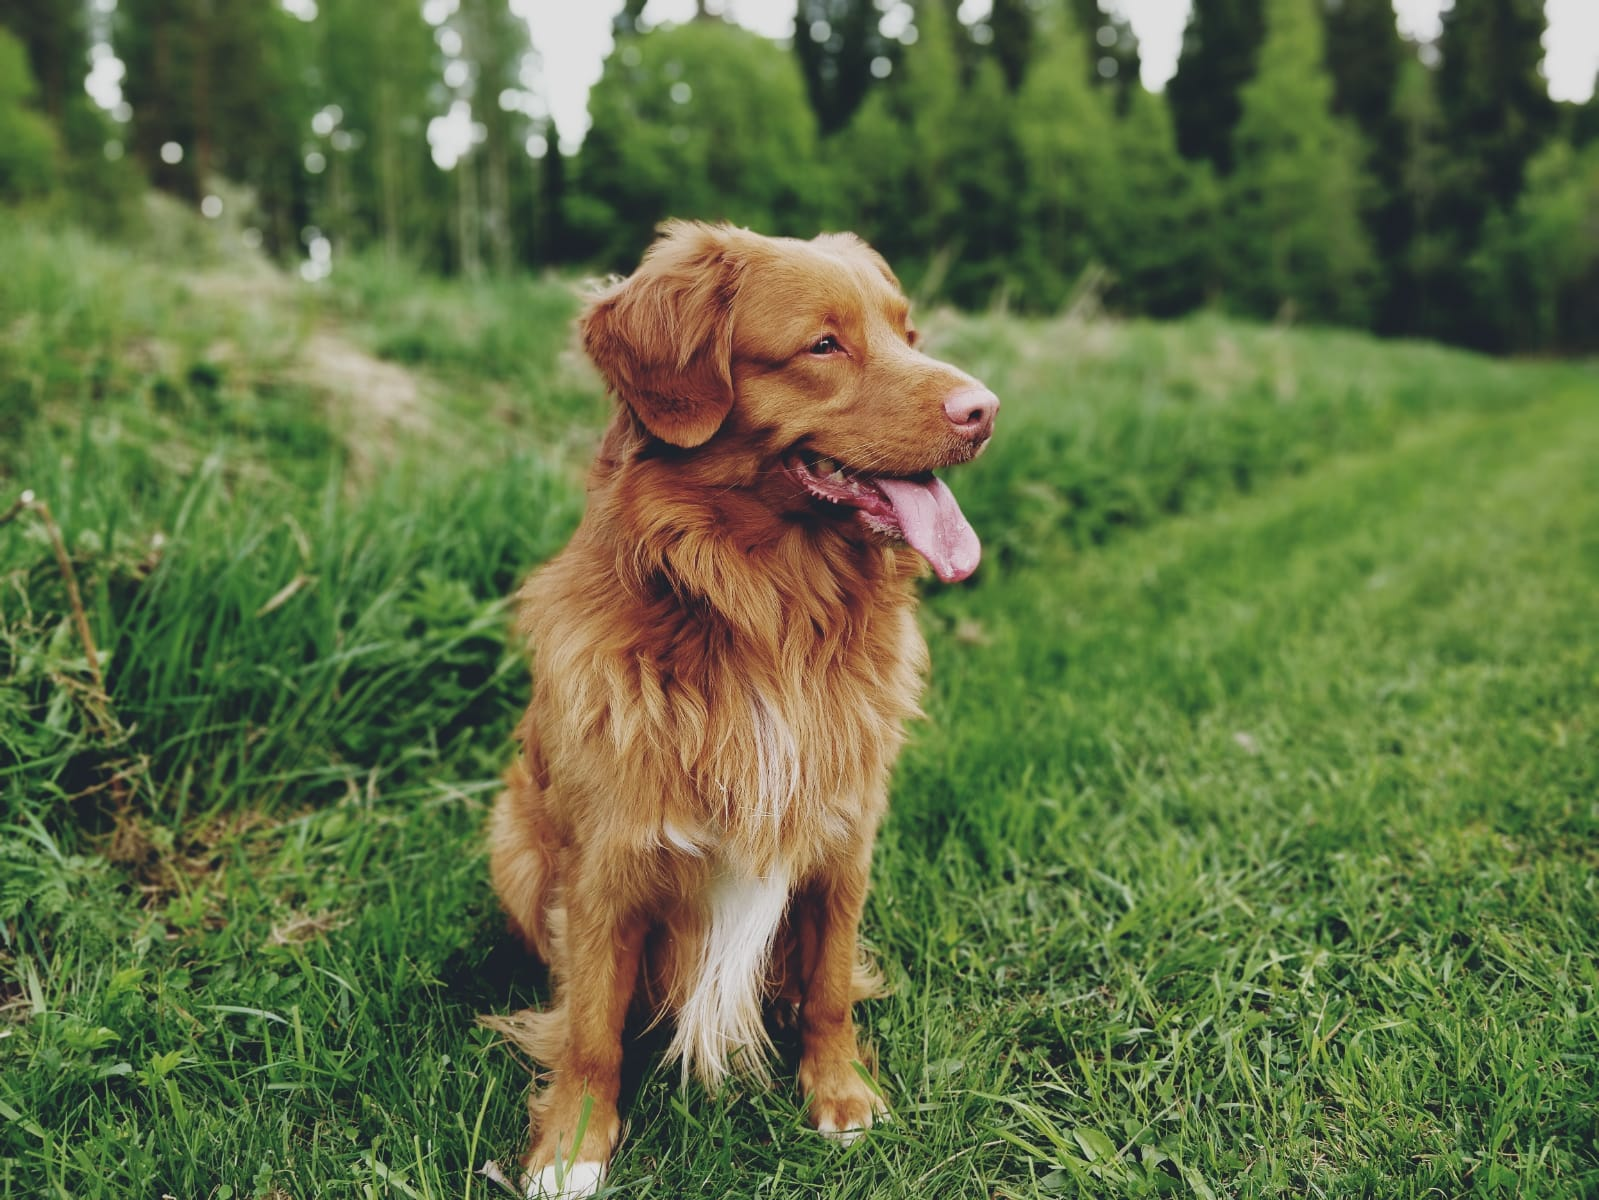

In [139]:
from PIL import Image

image = Image.open(image_path)
image

In [140]:
# Run a prediction on the deployed endpoint
print(f"Opening image {image_path}...")
with open(image_path, "rb") as f:
    img_bytes = f.read()

print("Predicting class...")
response = predictor.predict(
    img_bytes,
    initial_args={"ContentType": "image/jpeg"}
)

probs = np.array(response).flatten()

predicted_idx = int(np.argmax(probs))
confidence = float(np.max(probs))

print("Predicted class index:", predicted_idx)
print("Predicted class name:", class_names[predicted_idx])
print("Confidence:", confidence)

Opening image DuckToller.jpg...
Predicting class...
Predicted class index: 111
Predicted class name: 112.Nova_scotia_duck_tolling_retriever
Confidence: 0.727396547794342


## Prediction Test #2

In [141]:
s3 = boto3.client("s3")
s3.download_file(
    "uda-mleng-project3",
    "dogImagesDataset/inference/Schaeferhund.jpg",
    "Schaeferhund.jpg"
)

image_path = "Schaeferhund.jpg"

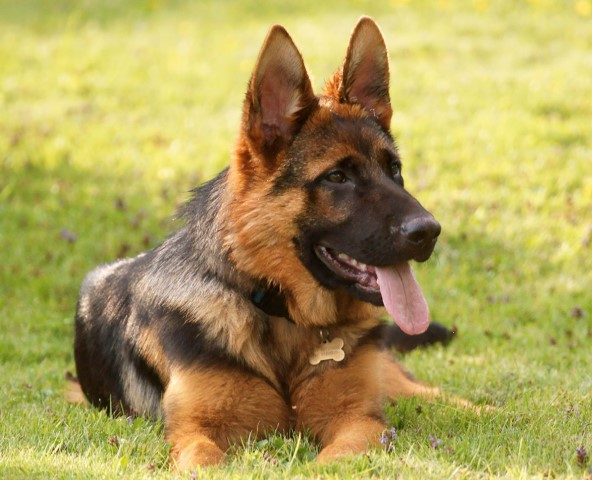

In [142]:
from PIL import Image

image = Image.open(image_path)
image

In [143]:
# Run a prediction on the deployed endpoint
print(f"Opening image {image_path}...")
with open(image_path, "rb") as f:
    img_bytes = f.read()

print("Predicting class...")
response = predictor.predict(
    img_bytes,
    initial_args={"ContentType": "image/jpeg"}
)

probs = np.array(response).flatten()

predicted_idx = int(np.argmax(probs))
confidence = float(np.max(probs))

print("Predicted class index:", predicted_idx)
print("Predicted class name:", class_names[predicted_idx])
print("Confidence:", confidence)

Opening image Schaeferhund.jpg...
Predicting class...
Predicted class index: 70
Predicted class name: 071.German_shepherd_dog
Confidence: 0.977985143661499


## Prediction Test #3

In [144]:
s3 = boto3.client("s3")
s3.download_file(
    "uda-mleng-project3",
    "dogImagesDataset/inference/Poodle.jpg",
    "Poodle.jpg"
)

image_path = "Poodle.jpg"

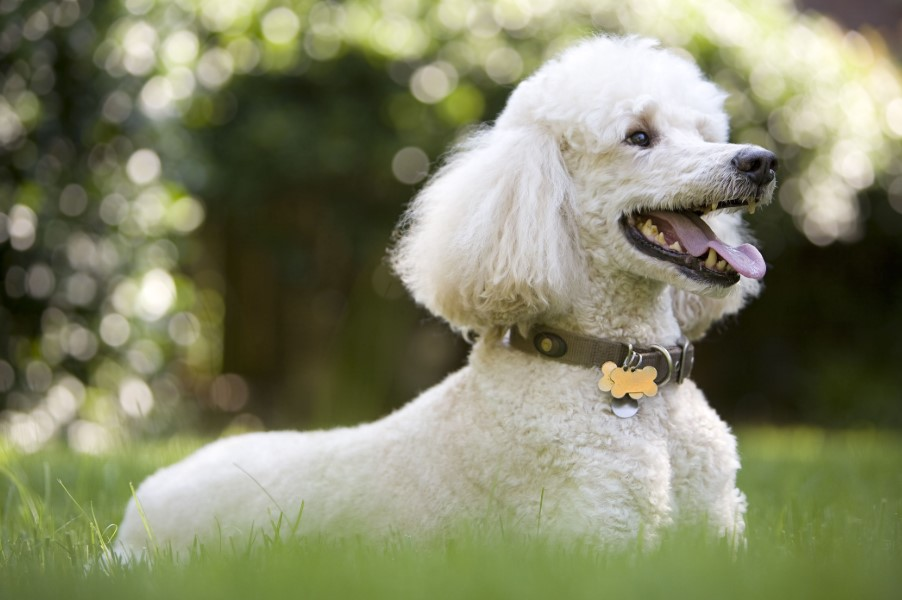

In [145]:
from PIL import Image

image = Image.open(image_path)
image

In [146]:
# Run a prediction on the deployed endpoint
print(f"Opening image {image_path}...")
with open(image_path, "rb") as f:
    img_bytes = f.read()

print("Predicting class...")
response = predictor.predict(
    img_bytes,
    initial_args={"ContentType": "image/jpeg"}
)

probs = np.array(response).flatten()

predicted_idx = int(np.argmax(probs))
confidence = float(np.max(probs))

print("Predicted class index:", predicted_idx)
print("Predicted class name:", class_names[predicted_idx])
print("Confidence:", confidence)

Opening image Poodle.jpg...
Predicting class...
Predicted class index: 23
Predicted class name: 024.Bichon_frise
Confidence: 0.7163467407226562


Here is a system screenshot of the deployed endpoint 'in service':

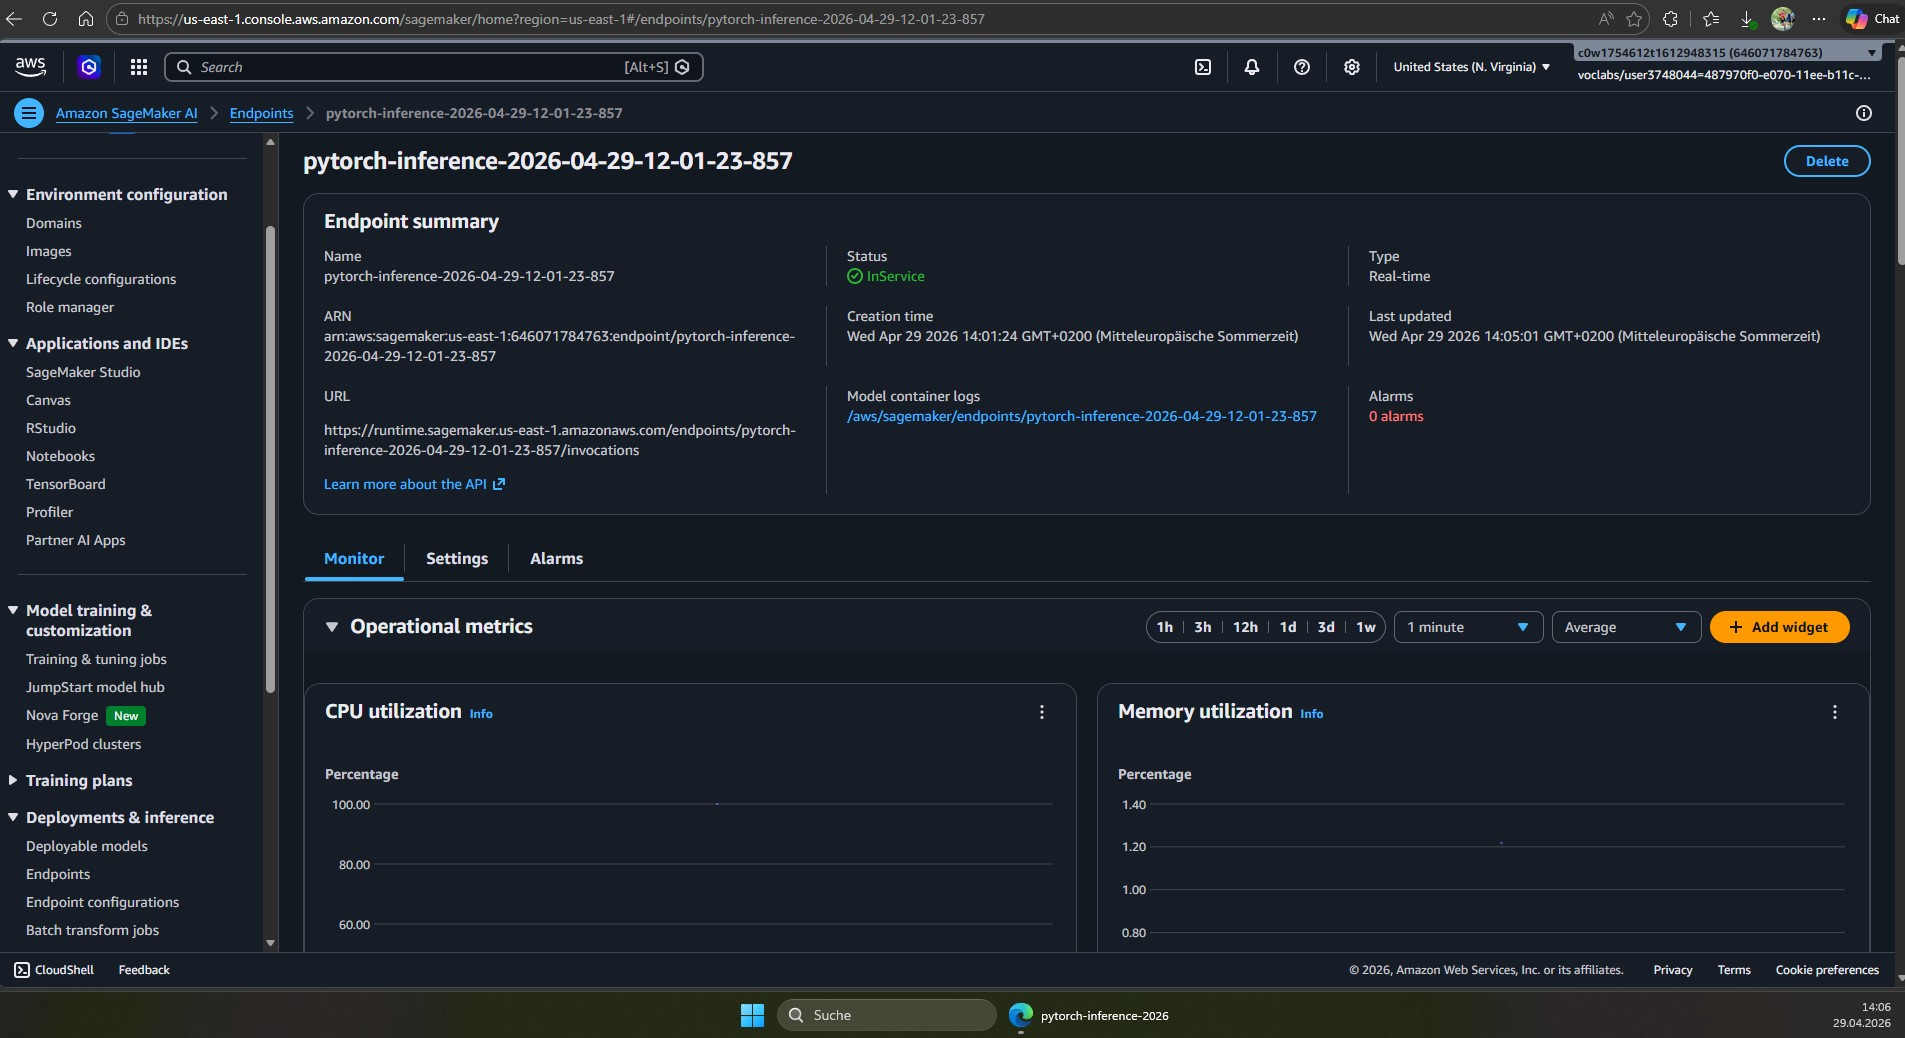

In [148]:
image_path = "Endpoint_Screenshot.jpg"

image = Image.open(image_path)
image

## Comments on predictions

- All 3 predictions pointed to the correct dog classes
- The confidences were very high, with values of 72.7%, 97.8% and 71.6%, respectively

## Finally, delete endpoint

In [134]:
# TODO: Remember to shutdown/delete your endpoint once your work is done
predictor.delete_endpoint()

INFO:sagemaker:Deleting endpoint configuration with name: pytorch-inference-2026-04-29-11-50-35-546
INFO:sagemaker:Deleting endpoint with name: pytorch-inference-2026-04-29-11-50-35-546
